In [4]:
import os
proxy = 'http://127.0.0.1:7897'
os.environ['http_proxy'] = proxy
os.environ['https_proxy'] = proxy

#os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"
from diffusers import AutoencoderKL
vae = AutoencoderKL.from_pretrained("runwayml/stable-diffusion-v1-5/", subfolder="vae", resume_download=True)
vae.requires_grad_(False)

OSError: We couldn't connect to 'https://huggingface.co' to load this model, couldn't find it in the cached files and it looks like runwayml/stable-diffusion-v1-5/ is not the path to a directory containing a config.json file.
Checkout your internet connection or see how to run the library in offline mode at 'https://huggingface.co/docs/diffusers/installation#offline-mode'.

In [2]:
import requests

proxy = {'http': 'http://127.0.0.1:7897', 'https': 'http://127.0.0.1:7897'}
response = requests.get("https://huggingface.co", proxies=proxy)
print(response.status_code) 

200


In [57]:
import os
import open_clip
import torch
proxy = 'http://127.0.0.1:7897'
os.environ['http_proxy'] = proxy
os.environ['https_proxy'] = proxy
cuda_device_count = torch.cuda.device_count()
print(cuda_device_count)
device = "cuda:0" if torch.cuda.is_available() else "cpu"
# vlmodel, preprocess = clip.load("ViT-B/32", device=device)
model_type = 'ViT-H-14'
vlmodel, preprocess_train, feature_extractor = open_clip.create_model_and_transforms(
    model_type, pretrained='laion2b_s32b_b79k', precision='fp32', device = device)
vlmodel.requires_grad_(False)

1


CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 1280, kernel_size=(14, 14), stride=(14, 14), bias=False)
    (patch_dropout): Identity()
    (ln_pre): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): ModuleList(
        (0-31): 32 x ResidualAttentionBlock(
          (ln_1): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=1280, out_features=1280, bias=True)
          )
          (ls_1): Identity()
          (ln_2): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=1280, out_features=5120, bias=True)
            (gelu): GELU(approximate='none')
            (c_proj): Linear(in_features=5120, out_features=1280, bias=True)
          )
          (ls_2): Identity()
        )
      )
    )
    (ln_post): LayerNorm((1280,), eps=1e-05, elementwi

In [4]:
from huggingface_hub import hf_hub_download
import os

proxy = 'http://127.0.0.1:7897'
os.environ['http_proxy'] = proxy
os.environ['https_proxy'] = proxy

# 测试文件下载
file_path = hf_hub_download(repo_id="runwayml/stable-diffusion-v1-5", filename="vae/config.json")
print(file_path)

C:\Users\Agatha\.cache\huggingface\hub\models--runwayml--stable-diffusion-v1-5\snapshots\f03de327dd89b501a01da37fc5240cf4fdba85a1\vae\config.json


In [3]:
from huggingface_hub import HfApi

api = HfApi()
models = api.list_models(search="stable-diffusion")
print([model.modelId for model in models[:5]])

TypeError: 'generator' object is not subscriptable

In [2]:
from diffusers import StableDiffusionPipeline, StableDiffusionImg2ImgPipeline

model_id = "runwayml/stable-diffusion-v1-5"
stable_diffusion_txt2img = StableDiffusionPipeline.from_pretrained(model_id)

D:\Program\anaconda3\envs\BCI\lib\site-packages\huggingface_hub\file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

scheduler/scheduler_config.json:   0%|          | 0.00/308 [00:00<?, ?B/s]

tokenizer/merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

...

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Error while downloading from https://cdn-lfs.hf.co/repos/66/6f/666f465fa70158515404e8de2c6bc6fe2f90c46f9296293aa14daededeb32c52/19da7aaa4b880e59d56843f1fcb4dd9b599c28a1d9d9af7c1143057c8ffae9f1?response-content-disposition=inline%3B+filename*%3DUTF-8%27%27diffusion_pytorch_model.safetensors%3B+filename%3D%22diffusion_pytorch_model.safetensors%22%3B&Expires=1734443609&Policy=eyJTdGF0ZW1lbnQiOlt7IkNvbmRpdGlvbiI6eyJEYXRlTGVzc1RoYW4iOnsiQVdTOkVwb2NoVGltZSI6MTczNDQ0MzYwOX19LCJSZXNvdXJjZSI6Imh0dHBzOi8vY2RuLWxmcy5oZi5jby9yZXBvcy82Ni82Zi82NjZmNDY1ZmE3MDE1ODUxNTQwNGU4ZGUyYzZiYzZmZTJmOTBjNDZmOTI5NjI5M2FhMTRkYWVkZWRlYjMyYzUyLzE5ZGE3YWFhNGI4ODBlNTlkNTY4NDNmMWZjYjRkZDliNTk5YzI4YTFkOWQ5YWY3YzExNDMwNTdjOGZmYWU5ZjE%7EcmVzcG9uc2UtY29udGVudC1kaXNwb3NpdGlvbj0qIn1dfQ__&Signature=D8onW35qePpzIFMBi52m3kpoyoJyKo7pCBwZd6kDAcj5OwCVs7uzMd2o0lGoM1sN1cSlkBRJHm%7EaLOnMKvpcJ248SvNMAb1acUuv-eLqESQuSC3j8dNLbR4-c2rLK1a77Mbi694uOyJPO4fA%7Ep%7ETbSYDrDUfyHGQReDY%7EZLYab3YQJPMzQ4AfAKNG2AixkQJmrMpBx5UOfJS7WAQpQK8Lc0UkXTSMJB

diffusion_pytorch_model.safetensors:  48%|####8     | 1.67G/3.44G [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["id2label"]` will be overriden.
D:\Program\anaconda3\envs\BCI\lib\site-packages\diffusers\utils\outputs.py:63: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(


In [1]:
from diffusers import AutoencoderKL
vae = AutoencoderKL.from_pretrained("./stable-diffusion-v1-5/", subfolder="vae")
vae.requires_grad_(False)

D:\Program\anaconda3\envs\BCI\Lib\site-packages\diffusers\utils\outputs.py:63: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(


AutoencoderKL(
  (encoder): Encoder(
    (conv_in): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (down_blocks): ModuleList(
      (0): DownEncoderBlock2D(
        (resnets): ModuleList(
          (0-1): 2 x ResnetBlock2D(
            (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
            (conv1): LoRACompatibleConv(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (norm2): GroupNorm(32, 128, eps=1e-06, affine=True)
            (dropout): Dropout(p=0.0, inplace=False)
            (conv2): LoRACompatibleConv(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (nonlinearity): SiLU()
          )
        )
        (downsamplers): ModuleList(
          (0): Downsample2D(
            (conv): LoRACompatibleConv(128, 128, kernel_size=(3, 3), stride=(2, 2))
          )
        )
      )
      (1): DownEncoderBlock2D(
        (resnets): ModuleList(
          (0): ResnetBlock2D(
            (norm1): GroupNorm(32, 128, ep

In [2]:
import os
import json

# Load the configuration from the JSON file
config_path = "data_config.json"
with open(config_path, "r") as config_file:
    config = json.load(config_file)

# Access the paths from the config
data_path = config["data_path"]
img_directory_training = config["img_directory_training"]
img_directory_test = config["img_directory_test"]

In [10]:
from torchvision import transforms
from PIL import Image
transform = transforms.Compose([
            transforms.Resize(512, interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.CenterCrop(512),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
        ])
device = "cuda:0"
vae.to(device)
raw_image = Image.open(os.path.join(img_directory_training, "00001_aardvark","aardvark_01b.jpg"))
image = transform(raw_image.convert("RGB"))
image = image.unsqueeze(0).to(device)
print(image.shape)
#image_enc = vae.encode(2*image-1).latent_dist.mode() * 0.18215
image_enc = vae.encode(image).latent_dist.mode() * 0.18215
print(image_enc.shape)

torch.Size([1, 3, 512, 512])
torch.Size([1, 4, 64, 64])


In [40]:
latents = vae.encode(image.to(device)).latent_dist.sample()

In [25]:
import torch
def pil_to_latents(image,vae):
    print(transforms.ToTensor()(image).shape)
    image = image.convert("RGB").resize((512,512))
    init_image = transforms.ToTensor()(image).unsqueeze(0) * 2.0 - 1.0
    init_image = init_image.to(device="cuda:0")
    print(init_image.shape)
    init_latent_dist = vae.encode(init_image).latent_dist.sample() * 0.18215
    return init_latent_dist
raw_image_latent = pil_to_latents(raw_image,vae)
print(raw_image_latent.shape)

torch.Size([3, 500, 500])
torch.Size([1, 3, 512, 512])
torch.Size([1, 4, 64, 64])


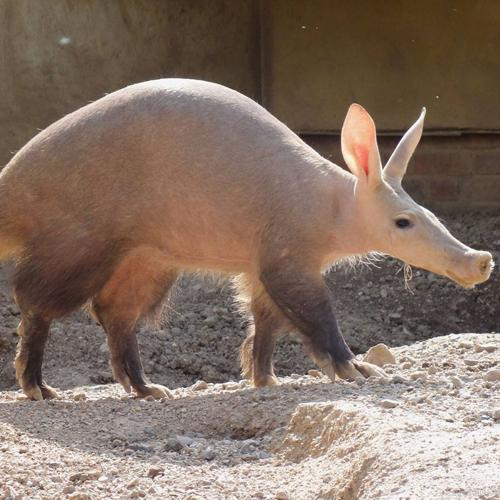

In [15]:
display(raw_image)

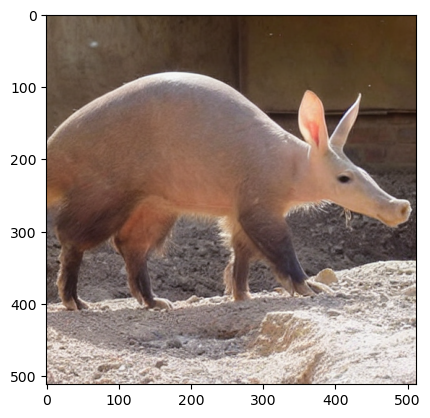

In [28]:
import matplotlib.pyplot as plt
def latent_to_pil(latents,vae):
    latents = (1/0.18215) * latents
    with torch.no_grad():
        image = vae.decode(latents).sample

    image = (image / 2 + 0.5).clamp(0,1)
    image = image.detach().cpu().permute(0,2,3,1).numpy()
    images = (image * 255).round().astype("uint8")
    pil_images = [ Image.fromarray(image) for image in images ]
    return pil_images
recon_image = latent_to_pil(raw_image_latent, vae)
plt.imshow(recon_image[0])
plt.show()

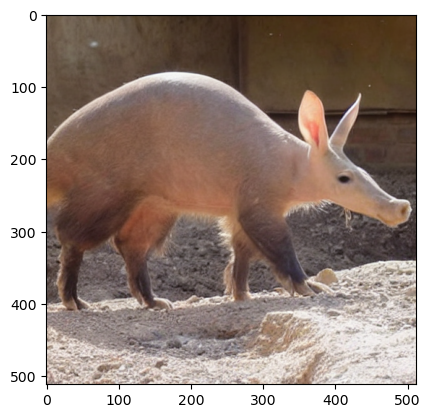

In [43]:
def latent_to_img(latents,vae):
    latents = (1/0.18215) * latents
    with torch.no_grad():
        image = vae.decode(latents).sample

    image = (image / 2 + 0.5).clamp(0,1)
    image = image.detach().cpu().permute(0,2,3,1).numpy()
    images = (image * 255).round().astype("uint8")
    recon_images = [Image.fromarray(image) for image in images ]
    return recon_images
recon_image_two = latent_to_img(image_enc, vae)
plt.imshow(recon_image_two[0])
plt.show()

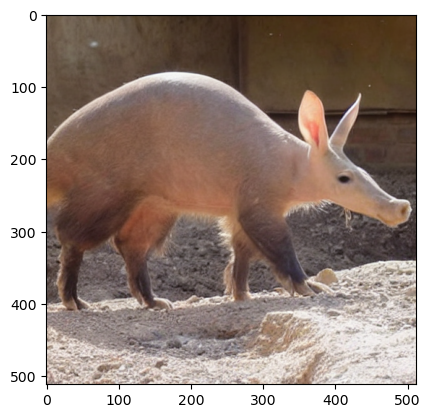

In [43]:
def latent_to_img(latents,vae):
    latents = (1/0.18215) * latents
    with torch.no_grad():
        image = vae.decode(latents).sample

    image = (image / 2 + 0.5).clamp(0,1)
    image = image.detach().cpu().permute(0,2,3,1).numpy()
    images = (image * 255).round().astype("uint8")
    recon_images = [Image.fromarray(image) for image in images ]
    return recon_images
recon_image_two = latent_to_img(image_enc, vae)
plt.imshow(recon_image_two[0])
plt.show()

In [1]:
import torch
print(torch.__version__)
print(torch.cuda.is_available()) 

2.5.0+cu124
True


In [6]:
cuda_device_count = torch.cuda.device_count()
print(cuda_device_count)

0


In [1]:
torch.cuda.is_available()

NameError: name 'torch' is not defined

In [3]:
import os
import json

# Load the configuration from the JSON file
config_path = "data_config.json"
with open(config_path, "r") as config_file:
    config = json.load(config_file)

# Access the paths from the config
data_path = config["data_path"]
img_directory_training = config["img_directory_training"]
img_directory_test = config["img_directory_test"]

directory = img_directory_training
dirnames = [d for d in os.listdir(directory) if os.path.isdir(os.path.join(directory, d))]
dirnames.sort()
image_folders = dirnames
images = []
for folder in image_folders:
    floder_path = os.path.join(directory, folder)
    all_images = [img for img in os.listdir(floder_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
    all_images.sort()
    images.extend(os.path.join(floder_path, img) for img in all_images)

In [4]:
print(len(images))

16540


In [59]:
texts = []
text_folders = dirnames
for dir in text_folders:                
    try:
        idx = dir.index('_')
        text_description = dir[idx + 1:]
    except ValueError:
        print(f"Skipped: {dir} due to no '_' found.")
        continue
                    
    new_text_description = f"This picture is {text_description}"
    texts.append(new_text_description)

In [60]:
print(len(texts))

1654


In [5]:
def VAEImageEncoder(images):
    transform = transforms.Compose([
            transforms.Resize(512, interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.CenterCrop(512),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
        ])
    batch_size = 20  
    image_emdeddings_list = []
      
    for i in range(0, len(images), batch_size):
        batch_images = images[i:i + batch_size]
        image_inputs = torch.stack([transform(Image.open(img).convert("RGB")) for img in batch_images]).to(device)

        with torch.no_grad():
            batch_image_emdedding = vae.encode(image_inputs).latent_dist.mode() * 0.18215

        image_emdeddings_list.append(batch_image_emdedding)

    image_features = torch.cat(image_emdeddings_list, dim=0)
    return image_features

In [11]:
from torchvision import transforms
import torch
from PIL import Image
device = "cuda:0"
vae.to(device)
img_vae_latents = VAEImageEncoder(images)
print(img_vae_latents.shape)

torch.Size([16540, 4, 64, 64])


In [67]:
img_vae_latents.shape

torch.Size([827, 4, 64, 64])

In [80]:
image_emdeddings_list = []
transform = transforms.Compose([
            transforms.Resize(512, interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.CenterCrop(512),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
        ])      
for i in range(0, 40, 20):
    batch_images = images[i:i + 20]
    image_inputs = torch.stack([transform(Image.open(img).convert("RGB")) for img in batch_images]).to(device)
    print(image_inputs.shape)
    print(image_inputs[0].shape)

    with torch.no_grad():
        batch_image_emdedding = vae.encode(image_inputs).latent_dist.mode() * 0.18215

    image_emdeddings_list.append(batch_image_emdedding)
image_features = torch.cat(image_emdeddings_list, dim=0)
print(image_features.shape)

torch.Size([20, 3, 512, 512])
torch.Size([3, 512, 512])
torch.Size([20, 3, 512, 512])
torch.Size([3, 512, 512])
torch.Size([40, 4, 64, 64])


In [73]:
import torch.nn.functional as F
def ClipImageEncoder(images):
    # Prevent memory overflow on the GPU
    batch_size = 20  
    image_features_list = []
      
    for i in range(0, len(images), batch_size):
        batch_images = images[i:i + batch_size]
        image_inputs = torch.stack([preprocess_train(Image.open(img).convert("RGB")) for img in batch_images]).to(device)

        with torch.no_grad():
            # vlmodel.encode_image
            batch_image_features = vlmodel.encode_image(image_inputs)
            # batch_image_features /= batch_image_features.norm(dim=-1, keepdim=True)
            batch_image_features = F.normalize(batch_image_features, dim=-1).detach()

        image_features_list.append(batch_image_features)

    clip_image_features = torch.cat(image_features_list, dim=0)
        
    return clip_image_features

In [74]:
img_clip_latents = ClipImageEncoder(images)
print(img_clip_latents.shape)

torch.Size([16540, 1024])


In [29]:
import numpy as np
def load_eeg_data(train, subject, avg):
    if train:
        file_name = 'preprocessed_eeg_training.npy'
        n_classes = 1654
        samples_per_class = 10
        repeat_times = 4
    else:
        file_name = 'preprocessed_eeg_test.npy'
        n_classes = 200
        samples_per_class = 1
        repeat_times = 80

    file_path = os.path.join(data_path, subject, file_name)
    data = np.load(file_path, allow_pickle=True)

    preprocessed_eeg_data = torch.from_numpy(data['preprocessed_eeg_data']).float().detach()
    times = torch.from_numpy(data['times']).detach()[20:]
    ch_names = data['ch_names']
    #self.times = times
    #self.ch_names = ch_names

    eeg_data_list = []
    label_list = []
    for i in range(n_classes):
        start_index = i * samples_per_class
        eeg_data = preprocessed_eeg_data[start_index: start_index + samples_per_class]
        if avg:
            labels = torch.full((samples_per_class,), i, dtype=torch.long).detach()
        else:
            labels = torch.full((samples_per_class * repeat_times,), i, dtype=torch.long).detach()
        if avg:
            eeg_data = torch.mean(eeg_data, 1)
        eeg_data_list.append(eeg_data)
        label_list.append(labels)
    return eeg_data_list, label_list

config_path = "data_config.json"
with open(config_path, "r") as config_file:
    config = json.load(config_file)

# Access the paths from the config
data_path = config["data_path"]

train_list, train_label_list = load_eeg_data(True, 'sub-08', False)
test_list, test_label_list = load_eeg_data(False, 'sub-08', False)
train_list_avg, train_label_list_avg = load_eeg_data(True, 'sub-08', True)
test_list_avg, test_label_list_avg = load_eeg_data(False, 'sub-08', True)
print(train_list[0].shape)
print(test_list[0].shape)
print(train_list_avg[0].shape)
print(test_list_avg[0].shape)

torch.Size([10, 4, 63, 100])
torch.Size([1, 80, 63, 100])
torch.Size([10, 63, 100])
torch.Size([1, 63, 100])


In [30]:
eeg_data_tensor = torch.cat(test_list_avg, dim=0).view(-1, *test_list_avg[0].shape[-2:])
print("eeg_data_tensor:", eeg_data_tensor.shape)
label_tensor = torch.cat(train_label_list_avg, dim=0)
print("label_tensor:", label_tensor.shape)

eeg_data_tensor: torch.Size([200, 63, 100])
label_tensor: torch.Size([16540])


In [ ]:
import torch
device = "cuda:0"

device
class DataEmbedding(nn.Module):
    def __init__(self, c_in, d_model, embed_type='fixed', freq='h', dropout=0.1, joint_train=False, num_subjects=None):
        super(DataEmbedding, self).__init__()
        if joint_train and num_subjects is not None:
            self.value_embedding = nn.ModuleDict({
                str(subject_id): nn.Linear(c_in, d_model) for subject_id in range(num_subjects)
            })
        else:
            self.value_embedding = nn.Linear(c_in, d_model)  # 如果没有指定subjects，则使用单一的value embedding

        self.position_embedding = PositionalEmbedding(d_model=d_model)
        self.temporal_embedding = TemporalEmbedding(d_model=d_model, embed_type=embed_type, freq=freq) if embed_type != 'timeF' else TimeFeatureEmbedding(d_model=d_model, embed_type=embed_type, freq=freq)
        self.dropout = nn.Dropout(p=dropout)
        self.subject_embedding = SubjectEmbedding(num_subjects, d_model) if num_subjects is not None else None
        self.mask_token = nn.Parameter(torch.randn(1, d_model))  # Mask token embedding
        self.joint_train = joint_train
        
    def forward(self, x, x_mark, subject_ids=None, mask=None):
        if self.joint_train:
            # 使用针对每个subject的特定value embedding
            x = torch.stack([self.value_embedding[str(subject_id.item())](x[i]) for i, subject_id in enumerate(subject_ids)])
        else:
            x = self.value_embedding(x)

        if x_mark is not None:
            x = x + self.temporal_embedding(x_mark) + self.position_embedding(x)

        if mask is not None:
            x = x * (~mask.bool()) + self.mask_token * mask.float()

        if self.subject_embedding is not None:
            subject_emb = self.subject_embedding(subject_ids)  # (batch_size, 1, d_model)
            x = torch.cat([subject_emb, x], dim=1)  # 在序列维度上拼接 (batch_size, seq_len + 1, d_model)

        return self.dropout(x)
        
enc_embedding = DataEmbedding(configs.seq_len, configs.d_model, configs.embed, 
                              configs.freq, configs.dropout, joint_train=False, num_subjects=num_subjects)
enc_embedding.to(device)

for batch_idx, (eeg_data, labels, text, text_features, img, img_features) in enumerate(dataloader):
    eeg_data = eeg_data.to(device)
    eeg_features = enc_embedding(eeg_data, None)
    break

In [1]:
import torch
import numpy as np
import clip
from torch.nn import functional as F
from PIL import Image
import os
from torchvision import transforms
from transformers import CLIPTextModel
import json

# Load the configuration from the JSON file
data_config_path = "data_config.json"
with open(data_config_path, "r") as data_config_file:
    data_config = json.load(data_config_file)

# Access the paths from the config
pretrained_model_path = data_config["pretrained_model_path"]

text_encoder = CLIPTextModel.from_pretrained(pretrained_model_path, subfolder="text_encoder")
text_encoder.requires_grad_(False)

E:\Program\anaconda3\envs\BCI\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CLIPTextModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 768)
      (position_embedding): Embedding(77, 768)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=768, out_features=768, bias=True)
            (v_proj): Linear(in_features=768, out_features=768, bias=True)
            (q_proj): Linear(in_features=768, out_features=768, bias=True)
            (out_proj): Linear(in_features=768, out_features=768, bias=True)
          )
          (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=768, out_features=3072, bias=True)
            (fc2): Linear(in_features=3072, out_features=768, bias=True)
          )
          (layer_norm2): LayerNorm((768,), eps=1e

In [3]:
import os
import json
import torch

# Load the configuration from the JSON file
config_path = "data_config.json"
with open(config_path, "r") as config_file:
    config = json.load(config_file)

# Access the paths from the config
data_path = config["data_path"]
img_directory_training = config["img_directory_training"]
img_directory_test = config["img_directory_test"]

model_type = 'ViT-L-14'
features_filename = os.path.join(f'{model_type}_features_test.pt')
if os.path.exists(features_filename):
    saved_features = torch.load(features_filename)
    clip_text_features = saved_features['clip_text_features']
    clip_img_features = saved_features['clip_img_features']
    vae_img_features = saved_features['vae_img_features']
    clip_text_hidden_states = saved_features['clip_text_hidden_states']

print(clip_text_features.shape)

torch.Size([200, 768])


C:\Users\Agatha\AppData\Local\Temp\ipykernel_46120\131108276.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  saved_features = torch.load(features_filename)


In [4]:
300 % 1600

300

In [9]:
(16539 % 16540) // 10

1653

In [11]:
import numpy as np
import os
import json
import torch

file_name = 'preprocessed_eeg_training.npy'
n_classes = 1654
samples_per_class = 10
repeat_times = 4

config_path = "data_config.json"
with open(config_path, "r") as config_file:
    config = json.load(config_file)

# Access the paths from the config
data_path = config["data_path"]
subject = 'sub-08'
file_path = os.path.join(data_path, subject, file_name)
data = np.load(file_path, allow_pickle=True)

preprocessed_eeg_data = torch.from_numpy(data['preprocessed_eeg_data']).float().detach()
print(preprocessed_eeg_data.shape)

torch.Size([16540, 4, 63, 100])


In [12]:
import numpy as np
import os
import json
import torch

file_name = 'preprocessed_eeg_test.npy'
n_classes = 1654
samples_per_class = 10
repeat_times = 4

config_path = "data_config.json"
with open(config_path, "r") as config_file:
    config = json.load(config_file)

# Access the paths from the config
data_path = config["data_path"]
subject = 'sub-08'
file_path = os.path.join(data_path, subject, file_name)
data = np.load(file_path, allow_pickle=True)

preprocessed_eeg_data = torch.from_numpy(data['preprocessed_eeg_data']).float().detach()
print(preprocessed_eeg_data.shape)

torch.Size([200, 80, 63, 100])


In [1]:
import numpy as np
import os
import json
import torch

file_name = 'preprocessed_eeg_training.npy'
n_classes = 1654
samples_per_class = 10
repeat_times = 4

config_path = "data_config.json"
with open(config_path, "r") as config_file:
    config = json.load(config_file)

# Access the paths from the config
data_path = config["data_path"]
subject_list = os.listdir(data_path)
print(subject_list)

['sub-01', 'sub-02', 'sub-03', 'sub-04', 'sub-05', 'sub-06', 'sub-07', 'sub-08', 'sub-09', 'sub-10']
